# AssemLens • Heavy GB10 experiment v4

**Purpose:** an exploratory scale/temporal-evidence experiment, not a guaranteed accuracy upgrade. Your previous paired evaluation improved action exact match from 0% to 13.125% (21/160), verbs to 26.875% (43/160), and objects to 24.375% (39/160). Accuracy is still insufficient for unattended assembly verification.

## What increases
- 64 training recordings instead of 32, up to 180 examples each. Actual counts depend on annotation availability.
- Four chronological frames per action (10%, 35%, 65%, 90%) instead of two; these are ordered images, not native video input.
- Images up to 576 pixels per side instead of 448, with a matching processor pixel budget.
- Rank-32 / alpha-64 LoRA instead of rank-16 / alpha-32; approximately double the attention-adapter parameters.
- Up to 4 epochs and an 8-hour training-loop ceiling. Downloads, baseline generation and final evaluation are outside that ceiling. Early stopping may finish much sooner.

Keep Qwen3-VL-4B BF16 and SDPA so the successful HP software stack remains unchanged. Learning rate is lowered to 3e-5. Checkpoint/evaluate every 50 optimizer steps, early-stop after 3 non-improving monitored loss evaluations, restore lowest-loss checkpoint. Microbatch 1, accumulation 8, frozen vision encoder. This changes several variables together; it cannot isolate which change causes a gain or regression.

## Compare fairly
Retain 8 validation recordings, up to 180 examples per recording, and 160 representative generation samples. With the same dataset revision and successful frame extraction, this yields the same evaluation segment IDs as v3. A check below confirms that; do not claim identical evaluation if it fails. Four frames intentionally change the visual input. Start from base weights, not the old adapter. Test data remains untouched. A low loss or valid JSON alone does not show accurate perception.

## Resources and safety of the experiment
New root: repository `runs/assembly101_heavy_v4`; old runs and adapters are preserved. Videos use the HF cache, so previously downloaded files are reused. A conservative 90-GiB video cap and planned-video-size plus 15-GiB free-space gate run before downloads. Total model/frame/checkpoint disk usage is additional. Coordinate downloads and GPU use with your team. No concurrent model server or training job during this run.

Use your **existing project .venv**; do not rerun installation. Run all preparation cells in order, inspect all four frames, then run a fresh pilot before launching. The new worker/notebook have syntax and structural checks here, but have not been run on your HP GPU. No runtime or memory-fit guarantee. If the pilot runs out of memory, make a new ROOT, reduce image_side to 448 and the worker processor budget consistently, then revalidate; do not alter a running/resumable experiment.

With a September 25 submission deadline, keep another teammate working on product-state examples and the demo. This run remains toy-action recognition, not furniture/PC defect detection.


In [2]:
import sys, platform, shutil, subprocess, json, os, time
from pathlib import Path
import torch
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'scripts/train_assemlens_heavy.py').is_file()), None)
assert REPO, 'Open this notebook from the updated cloned repository.'
assert Path(sys.prefix).resolve() == (REPO/'.venv').resolve(), 'Select the project .venv kernel.'
assert torch.cuda.is_available() and torch.cuda.is_bf16_supported()
x=torch.randn(512,512,device='cuda',dtype=torch.bfloat16)
assert torch.isfinite(x@x).all().item()
del x; torch.cuda.empty_cache()
print(sys.executable, torch.__version__, torch.cuda.get_device_name(0))
ROOT=REPO/'runs'/'assembly101_heavy_v4'
ROOT.mkdir(parents=True,exist_ok=True)
FFMPEG=shutil.which('ffmpeg') or str(Path.home()/'miniforge3/envs/assemlens-media/bin/ffmpeg')
assert Path(FFMPEG).is_file(), 'Set FFMPEG to your installed executable.'
CFG=dict(root=str(ROOT), model='Qwen/Qwen3-VL-4B-Instruct',dataset='cvml-nus/assembly101',
         camera='C10404_rgb.mp4', train_recordings=64,validation_recordings=8,
         segments_per_recording=180,video_budget_gib=90,image_side=576,
         training_hours=8,epochs=4,learning_rate=3e-5,eval_steps=50,
         generation_eval_samples=160,loss_eval_samples=256)
CFG.update(frames_per_action=4,lora_rank=32,lora_alpha=64,processor_max_pixels=324*32*32)
print(json.dumps(CFG,indent=2))
print('Free disk GiB:',round(shutil.disk_usage(ROOT).free/2**30,1))


/home/hp15/git_happens/assemlens/.venv/bin/python 2.14.0+cu130 NVIDIA GB10
{
  "root": "/home/hp15/git_happens/assemlens/runs/assembly101_heavy_v4",
  "model": "Qwen/Qwen3-VL-4B-Instruct",
  "dataset": "cvml-nus/assembly101",
  "camera": "C10404_rgb.mp4",
  "train_recordings": 64,
  "validation_recordings": 8,
  "segments_per_recording": 180,
  "video_budget_gib": 90,
  "image_side": 576,
  "training_hours": 8,
  "epochs": 4,
  "learning_rate": 3e-05,
  "eval_steps": 50,
  "generation_eval_samples": 160,
  "loss_eval_samples": 256,
  "frames_per_action": 4,
  "lora_rank": 32,
  "lora_alpha": 64,
  "processor_max_pixels": 331776
}
Free disk GiB: 3363.5


## Inspect the old run's actual results (optional, read-only)
This resolves the stale “No final report yet” cell if the report now exists on the HP. Exact-match can reject synonyms; inspect prediction text and labels together. Don't infer improvement from low training loss alone.


In [3]:
previous=REPO/'runs/assembly101_scale_v3/overnight'
for name in ['comparison.json','baseline.json','adapted.json']:
    p=previous/name
    if p.exists():
        obj=json.loads(p.read_text())
        print(name, json.dumps(obj.get('metrics',obj if name=='comparison.json' else {}),indent=2))
        if name=='adapted.json':
            for r in obj.get('predictions',[])[:8]: print('LABEL:',r['target'],'PREDICTION:',r['prediction'])
    else: print('Not found:',p)


comparison.json {
  "baseline": {
    "action_exact_match": 0.0,
    "verb_exact_match": 0.00625,
    "object_exact_match": 0.0,
    "valid_json_fraction": 1.0,
    "n": 160,
    "action_macro_f1_supported_labels": 0.0,
    "verb_macro_f1_supported_labels": 0.005263157894736842,
    "object_macro_f1_supported_labels": 0.0,
    "generation_seconds_p50": 1.287716402002843,
    "generation_seconds_p95": 1.4269892620068276,
    "recordings": 8
  },
  "adapted": {
    "action_exact_match": 0.13125,
    "verb_exact_match": 0.26875,
    "object_exact_match": 0.24375,
    "valid_json_fraction": 1.0,
    "n": 160,
    "action_macro_f1_supported_labels": 0.05178317053317053,
    "verb_macro_f1_supported_labels": 0.18252129424280047,
    "object_macro_f1_supported_labels": 0.11071598679957813,
    "generation_seconds_p50": 1.3911398220079718,
    "generation_seconds_p95": 1.5657283399923472,
    "recordings": 8
  },
  "validation_loss": {
    "eval_loss": 0.24269282817840576,
    "eval_runtime": 

## Authenticate and lock revisions
Use the cached HF token. The official [Assembly101 download](https://huggingface.co/datasets/cvml-nus/assembly101) requires accepted access conditions (CC BY-NC 4.0). No unrestricted wget bypass is offered. The download calls below retrieve only selected files. Preserve config and model revision on reruns.


In [4]:
from huggingface_hub import HfApi, hf_hub_download, login, get_token
from getpass import getpass
if not get_token():
    login(token=getpass('Hugging Face read token: '), add_to_git_credential=False)
api = HfApi()
config_path=ROOT/'config.json'
if config_path.exists():
    saved=json.loads(config_path.read_text())
    assert all(saved.get(k)==v for k,v in CFG.items()), 'Configuration changed: choose a new ROOT.'
    CFG=saved
else:
    CFG['dataset_revision']=api.dataset_info(CFG['dataset']).sha
    CFG['model_revision']=api.model_info(CFG['model']).sha
# A small authorized download proves access before downloading any videos.
actions_path = hf_hub_download(CFG['dataset'], 'annotations/fine-grained-annotations/actions.csv',
                               repo_type='dataset', revision=CFG['dataset_revision'])
print('Access verified. Dataset revision:', CFG['dataset_revision'])
(ROOT / 'config.json').write_text(json.dumps(CFG, indent=2))
# Freeze installed package versions for the experiment; no credentials in this command.
(ROOT / 'environment.txt').write_text(subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'], text=True))


/home/hp15/miniforge3/envs/zgx/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Access verified. Dataset revision: bfc15ea5e3f0bc8f8c232af6c1b45aa137a9d967


13620

## Select recordings and check budget
Use official split labels, one camera and full-recording separation. Keep test untouched. Selection is deterministic; increasing recording counts retains a prefix of the earlier selected recordings, reusing cached videos. This is not class-balanced sampling. Annotation frame positions use 30 fps.


In [5]:
import pandas as pd
import random
columns = ['id','video','start_frame','end_frame','action_cls','verb_cls','noun_cls']
tables = {}
for split in ['train','validation']:
    path = hf_hub_download(CFG['dataset'], f'annotations/fine-grained-annotations/{split}.csv',
                           repo_type='dataset', revision=CFG['dataset_revision'])
    df = pd.read_csv(path, usecols=columns).dropna()
    df = df[df.video.str.endswith('/'+CFG['camera'])].copy()
    df['sequence'] = df.video.str.split('/').str[0]
    duration = (df.end_frame - df.start_frame)/30.0
    df = df[(duration >= 1.0) & (duration <= 30.0)].copy()
    tables[split] = df
# Exclude all official validation recording identities from the training pool.
val_sequences = set(tables['validation'].sequence)
tables['train'] = tables['train'][~tables['train'].sequence.isin(val_sequences)].copy()
selected = {}
for split in ['train','validation']:
    df = tables[split]
    sequences = sorted(df.sequence.unique())
    random.Random(42).shuffle(sequences)
    sequences = sequences[:CFG[split+'_recordings']]
    assert len(sequences) >= (2 if split == 'train' else 1), f'Too few {split} recordings.'
    selected[split] = pd.concat([df[df.sequence == seq].sample(n=min(CFG['segments_per_recording'], len(df[df.sequence == seq])), random_state=42) for seq in sequences]).sort_values(['video','start_frame'])
assert not (set(selected['train'].sequence) & set(selected['validation'].sequence))
video_plan=[]
for video in sorted(set(pd.concat(list(selected.values())).video)):
    sequence, camera = video.split('/')
    repo_path = 'recordings/'+video
    entries = list(api.list_repo_tree(CFG['dataset'], path_in_repo='recordings/'+sequence,
                                     repo_type='dataset', revision=CFG['dataset_revision']))
    matches=[e for e in entries if e.path == repo_path]
    assert len(matches)==1 and matches[0].size > 0, f'Missing video metadata: {repo_path}'
    video_plan.append(dict(video=video, path=repo_path, bytes=matches[0].size))
size=sum(v['bytes'] for v in video_plan)
print('Video download GiB:',round(size/2**30,2))
print({s:dict(recordings=int(d.sequence.nunique()), segments=len(d)) for s,d in selected.items()})
assert size <= CFG['video_budget_gib']*2**30, 'Budget exceeded: reduce recording counts and rerun selection. No videos downloaded yet.'
(ROOT/'video_plan.json').write_text(json.dumps(video_plan,indent=2))
for split, df in selected.items(): df.to_csv(ROOT/f'{split}_selection.csv',index=False)

assert shutil.disk_usage(ROOT).free > size + 15*2**30, 'Conservative free-space gate: reserve planned videos plus 15 GiB for frames/model/checkpoints.'


Video download GiB: 53.03
{'train': {'recordings': 64, 'segments': 6387}, 'validation': {'recordings': 8, 'segments': 995}}


## Download and extract frames
This preparation cell can take time. It decodes images at timestamps and resizes them. The new config explicitly supplies `image_side`, which was missing from the edited v2 configuration. Finish this cell before proceeding; partial frame extraction is not a ready dataset.


In [6]:
from PIL import Image, ImageOps, ImageDraw
import hashlib
videos={}
for i, item in enumerate(video_plan, 1):
    print(f'Downloading {i}/{len(video_plan)}:', item['video'], flush=True)
    videos[item['video']] = hf_hub_download(CFG['dataset'], item['path'], repo_type='dataset', revision=CFG['dataset_revision'])

def extract_frame(video, seconds, destination):
    destination=Path(destination)
    if destination.exists():
        with Image.open(destination) as im: im.verify()
        return
    temp=destination.with_suffix('.tmp.png')
    cmd=[FFMPEG,'-hide_banner','-loglevel','error','-y','-ss',f'{seconds:.4f}',
         '-i',str(video),'-frames:v','1',str(temp)]
    result=subprocess.run(cmd,capture_output=True,text=True,timeout=90)
    if result.returncode or not temp.exists():
        raise RuntimeError('Frame extraction failed: '+result.stderr[-500:])
    with Image.open(temp) as im:
        im=im.convert('RGB'); im.thumbnail((CFG['image_side'],CFG['image_side']))
        im.save(destination,quality=92)
    temp.unlink()

manifests={}; failures=[]
for split, df in selected.items():
    folder=ROOT/'frames'/split; folder.mkdir(parents=True,exist_ok=True)
    rows=[]
    for number, row in enumerate(df.itertuples(),1):
        key=hashlib.sha256(f'{split}:{row.video}:{row.id}:{row.start_frame}:{row.end_frame}'.encode()).hexdigest()[:20]
        start,end=row.start_frame/30.0,row.end_frame/30.0
        paths=[folder/f'{key}_{i}.jpg' for i in range(4)]
        try:
            for path, frac in zip(paths,[0.1,0.35,0.65,0.9]): extract_frame(videos[row.video],start+(end-start)*frac,path)
            rows.append(dict(id=key,sequence=row.sequence,video=row.video,start_seconds=start,end_seconds=end,
                             images=[str(p) for p in paths],target=dict(action=row.action_cls,verb=row.verb_cls,object=row.noun_cls)))
        except Exception as e:
            failures.append(dict(split=split,id=key,error=str(e)))
        if number%40==0: print(split,number,'/',len(df),flush=True)
    assert len(rows) >= 8, 'Too few decoded examples.'
    assert len(rows) >= 0.9*len(df), 'More than 10% failed to decode: inspect alignment/FFmpeg before training.'
    manifests[split]=rows
    (ROOT/f'{split}.jsonl').write_text(''.join(json.dumps(r)+'\n' for r in rows))
(ROOT/'decode_failures.json').write_text(json.dumps(failures,indent=2))
print('Prepared:',{s:len(r) for s,r in manifests.items()},'| decode failures:',len(failures))


train 40 / 6387
train 80 / 6387
train 120 / 6387
train 160 / 6387
train 200 / 6387
train 240 / 6387
train 280 / 6387
train 320 / 6387
train 360 / 6387
train 400 / 6387
train 440 / 6387
train 480 / 6387
train 520 / 6387
train 560 / 6387
train 600 / 6387
train 640 / 6387
train 680 / 6387
train 720 / 6387
train 760 / 6387
train 800 / 6387
train 840 / 6387
train 880 / 6387
train 920 / 6387
train 960 / 6387
train 1000 / 6387
train 1040 / 6387
train 1080 / 6387
train 1120 / 6387
train 1160 / 6387
train 1200 / 6387
train 1240 / 6387
train 1280 / 6387
train 1320 / 6387
train 1360 / 6387
train 1400 / 6387
train 1440 / 6387
train 1480 / 6387
train 1520 / 6387
train 1560 / 6387
train 1600 / 6387
train 1640 / 6387
train 1680 / 6387
train 1720 / 6387
train 1760 / 6387
train 1800 / 6387
train 1840 / 6387
train 1880 / 6387
train 1920 / 6387
train 1960 / 6387
train 2000 / 6387
train 2040 / 6387
train 2080 / 6387
train 2120 / 6387
train 2160 / 6387
train 2200 / 6387
train 2240 / 6387
train 2280 / 6387


In [7]:
assert len(manifests['train'])>=1000, 'Unexpectedly small training set: inspect selection and extraction.'
assert len({r['sequence'] for r in manifests['validation']})>=4
print('Ready dataset:',len(manifests['train']),len(manifests['validation']))
print('Approximate planned optimizer steps:',__import__('math').ceil(len(manifests['train'])/8)*CFG['epochs'])


Ready dataset: 6387 995
Approximate planned optimizer steps: 3196


In [8]:
# Confirm whether final generation samples match the previous run.
# Import only dependency-free sampling function via AST; do not load a model.
import ast, random
worker_tree=ast.parse((REPO/'scripts/train_assemlens_heavy.py').read_text())
sampler=next(x for x in worker_tree.body if isinstance(x,ast.FunctionDef) and x.name=='representative')
ns={'random':random}
exec(compile(ast.Module(body=[sampler],type_ignores=[]),'sampler','exec'),ns)
planned_ids=[r['id'] for r in ns['representative'](manifests['validation'],CFG['generation_eval_samples'])]
old_ids=REPO/'runs/assembly101_scale_v3/overnight/evaluation_ids.json'
if old_ids.exists():
    comparable=planned_ids==json.loads(old_ids.read_text())
    print('Same evaluation segment IDs as v3:',comparable)
    if not comparable: print('Do not report a paired v3/v4 comparison without re-evaluating on common IDs.')
else:
    comparable=False
    print('Previous evaluation IDs not found; pairing is unverified.')
(ROOT/'comparison_protocol.json').write_text(json.dumps({'same_ids_as_v3':comparable,'planned_ids':planned_ids},indent=2))


Same evaluation segment IDs as v3: True


4531

## Visual label check
Check chronology, visibility and action labels before spending compute. Repeated similar images are expected within a session, but labels should describe the visible activity. Furniture-state annotations are still a separate next stage.


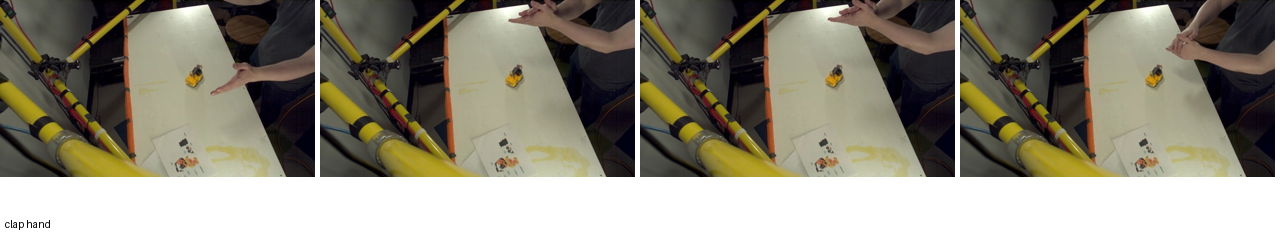

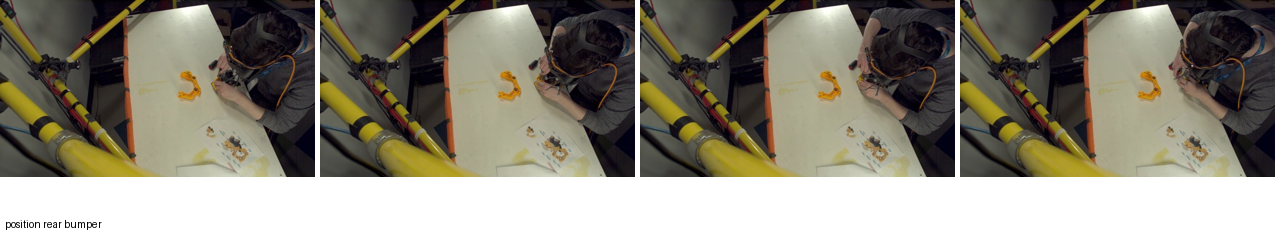

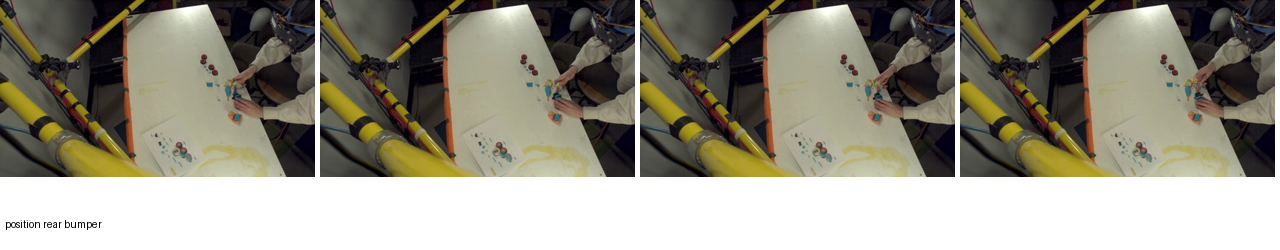

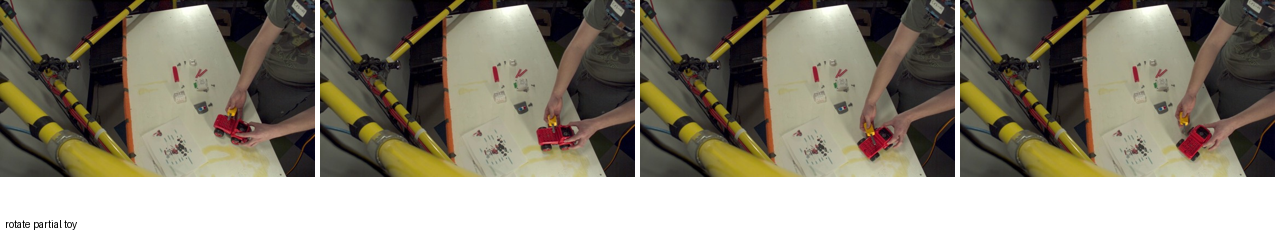

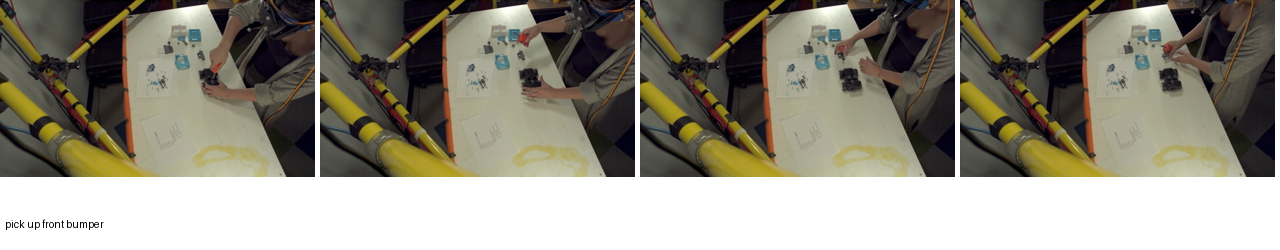

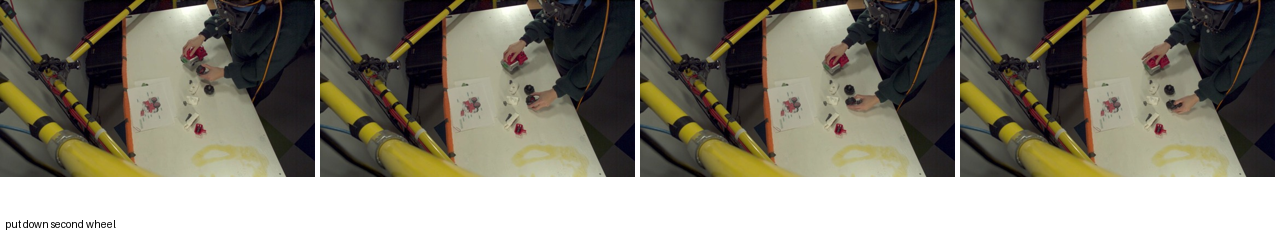

In [9]:
from IPython.display import display
for row in manifests['train'][::max(1,len(manifests['train'])//6)][:6]:
    canvas=Image.new('RGB',(1280,250),'white')
    for i,path in enumerate(row['images']):
        with Image.open(path) as im:
            tile=ImageOps.contain(im.convert('RGB'),(315,210)); canvas.paste(tile,(i*320,0))
    ImageDraw.Draw(canvas).text((5,218),row['target']['action'],fill='black')
    display(canvas)


## Freeze this run's worker and run a fresh pilot
The worker snapshot is immutable within this run. Resume signatures include full records, config and worker hash. The BF16-only TorchAO-dispatch workaround from your successful run is retained; this is not a quantized-training recipe. The pilot uses a separate folder and four validation examples. It verifies execution, not model quality.


In [10]:
WORKER=ROOT/'train_assemlens_heavy.py'
worker_source=(REPO/'scripts/train_assemlens_heavy.py').read_text()
if WORKER.exists():
    assert WORKER.read_text()==worker_source, 'Worker changed: use a new run ROOT.'
else: WORKER.write_text(worker_source)
pilot_status=ROOT/'pilot/status.json'
if pilot_status.exists() and json.loads(pilot_status.read_text()).get('state')=='finished':
    print('Existing pilot passed in this fixed run directory.')
else:
    with (ROOT/'pilot.log').open('a') as log:
        result=subprocess.run([sys.executable,'-u',str(WORKER),'--config',str(ROOT/'config.json'),'--pilot'],stdout=log,stderr=subprocess.STDOUT)
    print((ROOT/'pilot.log').read_text()[-12000:])
    assert result.returncode==0,'Pilot failed: inspect pilot.log before launching.'
assert json.loads(pilot_status.read_text())['state']=='finished'


W0923 06:04:23.159000 3202862 site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0923 06:04:23.174000 3202862 site-packages/torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 116.34it/s]
trainable params: 23,592,960 || all params: 4,461,408,768 || trainable%: 0.5288
Run root: /home/hp15/git_happens/assemlens/runs/assembly101_heavy_v4 Train: 16 Validation: 4 Generation eval: 4
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more 

## Launch once
Two epochs on the original tiny set took minutes; “overnight” is not a required duration. This run stops after its epoch/early-stop/time budget. Baseline generation, downloads and final evaluation are outside the eight-hour training budget. SSH disconnection can be tolerated by the detached worker, subject to lab policy. The HP must stay on.

Check that no other training/serving job is running first. Re-running this cell during startup is guarded by the stored PID; the worker also holds a run lock. A failed/interrupted run can resume the last checkpoint (at most 50 optimizer steps lost). Do not edit config/data/code while it runs.


In [11]:
assert json.loads((ROOT/'pilot/status.json').read_text())['state']=='finished'
status_path=ROOT/'overnight/status.json'
if status_path.exists():
    assert json.loads(status_path.read_text()).get('state')!='finished','Completed: inspect report, do not relaunch.'
pidfile=ROOT/'worker_pid.txt'
if pidfile.exists():
    try: os.kill(int(pidfile.read_text()),0)
    except ProcessLookupError: pass
    else: raise RuntimeError('Stored PID still exists. Inspect that process before launching another worker.')
with (ROOT/'overnight.log').open('a') as log:
    process=subprocess.Popen([sys.executable,'-u',str(WORKER),'--config',str(ROOT/'config.json')],stdin=subprocess.DEVNULL,stdout=log,stderr=subprocess.STDOUT,start_new_session=True)
pidfile.write_text(str(process.pid))
print('PID:',process.pid,'Run:',ROOT)


PID: 3203037 Run: /home/hp15/git_happens/assemlens/runs/assembly101_heavy_v4


In [12]:
# Monitor without starting another job.
if (ROOT/'overnight/status.json').exists(): print((ROOT/'overnight/status.json').read_text())
p=ROOT/'overnight.log'
if p.exists():
    with p.open('rb') as f:
        f.seek(max(0,p.stat().st_size-10000)); print(f.read().decode(errors='replace'))


## Results and error analysis
The saved adapter is the lowest periodic validation-loss checkpoint when one exists; otherwise the final state. Loss-based selection is not guaranteed to maximize action accuracy. Compare base/adapted generation on identical, session-spread samples. Macro F1 covers labels present in that evaluated subset. Report sample/recording counts and seen-label coverage. Do not compare percentages directly to the old first-40 subset as if the evaluation set were identical.

If JSON is valid but semantic accuracy remains weak, inspect vocabulary synonyms, alignment, image resolution and temporal evidence before expanding again. Use your final target-product footage for the correction task. This benchmark supplies known action boundaries and does not measure online segmentation.


In [13]:
import pandas as pd
out=ROOT/'overnight'
assert (out/'comparison.json').exists(), 'Job not finished or failed; inspect status and log.'
report=json.loads((out/'comparison.json').read_text())
print(json.dumps(report,indent=2))
display(pd.DataFrame({'base':report['baseline'],'adapted':report['adapted']}))
print('Train-label coverage:',(out/'coverage.json').read_text())
errors=json.loads((out/'adapted.json').read_text())['predictions']
for r in errors[:20]: print(r['sequence'], '\nLABEL:',r['target'],'\nPRED:',r['prediction'],'\n')
# Small reproducible report bundle: JSON/versions/code only, no images/weights/tokens.
import zipfile
bundle=ROOT/'review_bundle.zip'
with zipfile.ZipFile(bundle,'w',zipfile.ZIP_DEFLATED) as z:
    for name in ['comparison.json','baseline.json','adapted.json','coverage.json','training_arguments.json','evaluation_ids.json','trainer_state.json']:
        p=out/name
        if p.exists(): z.write(p,'results/'+name)
    for name in ['config.json','environment.txt','train_assemlens_heavy.py']:
        z.write(ROOT/name,name)
print('Share this bundle for analysis:',bundle)
print('Back up trained weights separately:',out/'adapter')


AssertionError: Job not finished or failed; inspect status and log.